# Equilibrium Propagation: A Hands-On Introduction

This notebook builds intuition for equilibrium propagation (EP) from scratch.
We implement a minimal EP system — a 2-layer network with a Hopfield-style
energy function — and demonstrate:

1. How the energy function defines the network
2. How free-phase settling finds the prediction
3. How nudged-phase settling encodes the gradient
4. The EP gradient theorem: comparing EP gradients with backprop
5. How beta affects gradient quality
6. Training a classifier with EP

In [1]:
using Pkg; Pkg.activate("..")
using LinearAlgebra, Statistics, Random, Plots
using Random: Xoshiro

  Activating project at `~/code/PhasorNetworks.jl`
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7]
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] 

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a](cache misses: wrong dep version loaded (1))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1. The Energy Function

In EP, a network is defined by an energy function over all neurons.
For a 2-layer MLP with input $x$, hidden state $h$, and output $o$:

$$\Phi(h, o; \theta, \beta) = \langle \sigma(W_1 x + b_1),\, h \rangle + \langle \sigma(W_2 h + b_2),\, o \rangle - \beta\, C(o, y)$$

where $\sigma$ is an activation (tanh), $C$ is the cost (MSE), and $\beta$ scales the teaching signal.

The key property: at equilibrium ($\partial\Phi/\partial h = 0$, $\partial\Phi/\partial o = 0$),
the network's state encodes the prediction (when $\beta=0$) or the nudged prediction (when $\beta>0$).

In [2]:
# Define a minimal EP network
struct EPNetwork
    W1::Matrix{Float64}   # input -> hidden
    b1::Vector{Float64}
    W2::Matrix{Float64}   # hidden -> output
    b2::Vector{Float64}
end

function EPNetwork(n_in, n_hid, n_out; rng=Xoshiro(42), scale=0.5)
    EPNetwork(
        randn(rng, n_hid, n_in) * scale,
        zeros(n_hid),
        randn(rng, n_out, n_hid) * scale,
        zeros(n_out)
    )
end

EPNetwork

In [3]:
# Energy function
function ep_energy(net::EPNetwork, x, h, o, y, beta)
    pre1 = net.W1 * x .+ net.b1
    pre2 = net.W2 * h .+ net.b2
    # Layer-wise interaction energy (bilinear form)
    E = dot(tanh.(pre1), h) + dot(tanh.(pre2), o)
    # Cost: simple MSE
    C = 0.5 * sum((o .- y).^2)
    return E - beta * C
end

# Cost function (for monitoring)
ep_cost(o, y) = 0.5 * sum((o .- y).^2)

ep_cost (generic function with 1 method)

## 2. Free Phase: Finding the Prediction

With $\beta = 0$, the network settles to the energy's natural equilibrium.
This is gradient ascent on $\Phi$ w.r.t. the neuron states:

$$h \leftarrow \sigma\!\left(\frac{\partial \Phi}{\partial h}\right) = \sigma\!\left(\sigma(W_1 x + b_1) + W_2^\top o\right)$$

$$o \leftarrow \sigma\!\left(\frac{\partial \Phi}{\partial o}\right) = \sigma\!\left(\sigma(W_2 h + b_2)\right)$$

Note: each neuron's update depends on both the layer below (feedforward)
and the layer above (feedback via $W_2^\top$). This is why **symmetric weights**
are required — the same $W_2$ sends information both ways.

In [4]:
function ep_settle!(net::EPNetwork, x, h, o, y, beta;
                    T=100, dt=0.5, record=false)
    energies = Float64[]
    
    for t in 1:T
        pre1 = net.W1 * x .+ net.b1
        pre2 = net.W2 * h .+ net.b2
        
        # dPhi/dh = sigma(W1*x + b1) + W2^T * [sigma'(pre2) .* o]
        grad_h = tanh.(pre1) .+ net.W2' * (sech.(pre2).^2 .* o)
        # dPhi/do = sigma(W2*h + b2) - beta * (o - y)
        grad_o = tanh.(pre2) .- beta .* (o .- y)
        
        # Damped update
        h .= (1 - dt) .* h .+ dt .* tanh.(grad_h)
        o .= (1 - dt) .* o .+ dt .* tanh.(grad_o)
        
        if record
            push!(energies, ep_energy(net, x, h, o, y, beta))
        end
    end
    
    return energies
end

ep_settle! (generic function with 1 method)

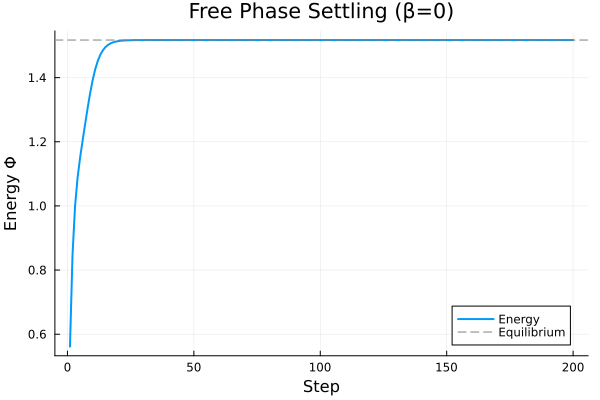

In [5]:
# Create network and run free phase
net = EPNetwork(2, 16, 1; scale=0.4)
x = [1.0, 0.5]  # single input
y = [1.0]        # target

h = zeros(16)
o = zeros(1)

energies_free = ep_settle!(net, x, h, o, y, 0.0; T=200, dt=0.5, record=true)

plot(energies_free, xlabel="Step", ylabel="Energy Φ",
     title="Free Phase Settling (β=0)", label="Energy",
     lw=2, legend=:bottomright)
hline!([energies_free[end]], ls=:dash, label="Equilibrium", color=:gray)

In [6]:
println("Free equilibrium:")
println("  h (first 5): ", round.(h[1:5], digits=4))
println("  o (prediction): ", round.(o, digits=4))
println("  target y: ", y)
println("  cost: ", round(ep_cost(o, y), digits=4))

Free equilibrium:
  h (first 5): [-0.1799, -0.2225, -0.0148, -0.1408, 0.0212]
  o (prediction): [0.5672]
  target y: [1.0]
  cost: 0.0936


## 3. Nudged Phase: Encoding the Gradient

Now we add the teaching signal: $\beta > 0$ pushes the output toward the target.
The system re-settles to a new equilibrium that's slightly closer to the correct answer.

The EP gradient theorem says: the difference in energy gradients between
the nudged and free equilibria, divided by $\beta$, gives the loss gradient:

$$\frac{dL}{d\theta} = \lim_{\beta \to 0} \frac{1}{\beta}\left[\left.\frac{\partial \Phi}{\partial \theta}\right|_{\text{nudge}} - \left.\frac{\partial \Phi}{\partial \theta}\right|_{\text{free}}\right]$$

In [7]:
# Compute EP gradient for one parameter (W1) at various beta
function ep_param_gradient(net, x, y, beta; T_free=200, T_nudge=100)
    # Free phase
    h_free = zeros(size(net.W1, 1))
    o_free = zeros(size(net.W2, 1))
    ep_settle!(net, x, h_free, o_free, y, 0.0; T=T_free)
    
    # Hebbian at free equilibrium: sigma'(pre) .* h * x'
    pre1_free = net.W1 * x .+ net.b1
    hebb_free = (sech.(pre1_free).^2 .* h_free) * x'
    
    # Nudged phase (start from free equilibrium)
    h_nudge = copy(h_free)
    o_nudge = copy(o_free)
    ep_settle!(net, x, h_nudge, o_nudge, y, beta; T=T_nudge)
    
    pre1_nudge = net.W1 * x .+ net.b1
    hebb_nudge = (sech.(pre1_nudge).^2 .* h_nudge) * x'
    
    # EP gradient: (nudge - free) / beta
    ep_grad = (hebb_nudge .- hebb_free) ./ beta
    
    return ep_grad, h_free, o_free, h_nudge, o_nudge
end

ep_param_gradient (generic function with 1 method)

In [8]:
# Finite-difference gradient (ground truth)
function fd_gradient_W1(net, x, y; eps=1e-5, T=200)
    function loss_at(W1)
        net_p = EPNetwork(W1, net.b1, net.W2, net.b2)
        h = zeros(size(W1, 1))
        o = zeros(size(net.W2, 1))
        ep_settle!(net_p, x, h, o, y, 0.0; T=T)
        return ep_cost(o, y)
    end
    
    grad = zeros(size(net.W1))
    base = loss_at(net.W1)
    for i in eachindex(net.W1)
        W1p = copy(net.W1)
        W1p[i] += eps
        grad[i] = (loss_at(W1p) - base) / eps
    end
    return grad
end

fd_gradient_W1 (generic function with 1 method)

## 4. The EP Gradient Theorem: Verification

Let's compare the EP gradient (from nudged - free equilibria) with the
true gradient (from finite differences) at various $\beta$ values.

The EP theorem is exact only as $\beta \to 0$. At finite $\beta$,
there's a bias that grows with $\beta$ (and worsens with network depth).

In [9]:
# Compute FD gradient (ground truth)
fd_grad = fd_gradient_W1(net, x, y; T=200)
println("FD gradient norm: ", round(norm(fd_grad), digits=6))

# Compare EP gradient at various beta
betas = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
cosines = Float64[]
ep_norms = Float64[]

for beta in betas
    ep_grad, _, _, _, _ = ep_param_gradient(net, x, y, beta; T_free=200, T_nudge=100)
    # Negate: EP gives dPhi/dW, we want dL/dW = -dPhi/dW
    ep_grad = -ep_grad
    cs = dot(vec(ep_grad), vec(fd_grad)) / (norm(vec(ep_grad)) * norm(vec(fd_grad)) + 1e-10)
    push!(cosines, cs)
    push!(ep_norms, norm(ep_grad))
end

println("\nBeta -> Cosine similarity with FD gradient:")
for (b, c) in zip(betas, cosines)
    println("  β=$(lpad(b, 5))  cos=$(round(c, digits=4))")
end

FD gradient norm: 0.163074

Beta -> Cosine similarity with FD gradient:
  β=0.001  cos=1.0
  β= 0.01  cos=1.0
  β= 0.05  cos=1.0
  β=  0.1  cos=1.0
  β=  0.2  cos=1.0
  β=  0.5  cos=1.0
  β=  1.0  cos=1.0
  β=  2.0  cos=0.9999
  β=  5.0  cos=0.9999


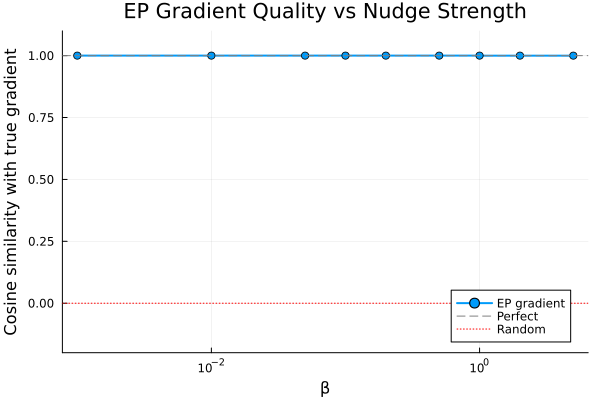

In [10]:
plot(betas, cosines, xlabel="β", ylabel="Cosine similarity with true gradient",
     title="EP Gradient Quality vs Nudge Strength",
     xscale=:log10, lw=2, marker=:circle, label="EP gradient",
     ylim=(-0.2, 1.1))
hline!([1.0], ls=:dash, color=:gray, label="Perfect")
hline!([0.0], ls=:dot, color=:red, label="Random")

## 5. The Small-Beta Dilemma

Small $\beta$ gives accurate gradients but tiny signal.
Large $\beta$ gives strong signal but biased gradients.

Let's visualize how the nudged equilibrium differs from the free equilibrium
at various $\beta$ values.

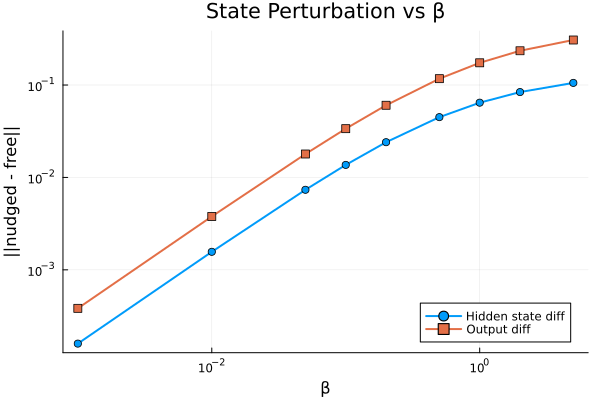

In [11]:
state_diffs = Float64[]
output_diffs = Float64[]

for beta in betas
    _, h_f, o_f, h_n, o_n = ep_param_gradient(net, x, y, beta; T_free=200, T_nudge=100)
    push!(state_diffs, norm(h_n .- h_f))
    push!(output_diffs, norm(o_n .- o_f))
end

plot(betas, state_diffs, xlabel="β", ylabel="||nudged - free||",
     title="State Perturbation vs β", xscale=:log10, yscale=:log10,
     lw=2, marker=:circle, label="Hidden state diff",
     legend=:bottomright)
plot!(betas, output_diffs, lw=2, marker=:square, label="Output diff")

## 6. Training with EP

Let's train the network on a simple classification task (XOR-like)
using EP gradients. We use a moderate $\beta$ and accept the bias.

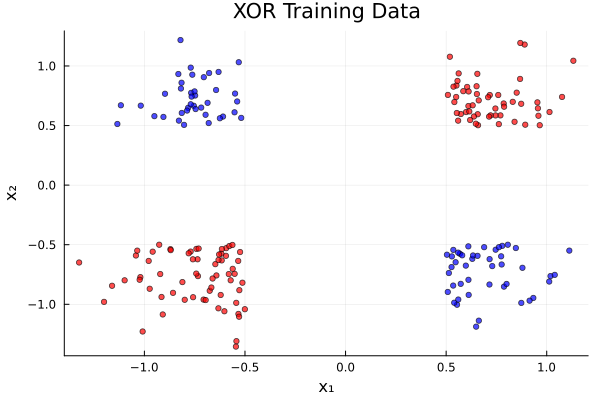

In [12]:
# Generate XOR-like data
function make_xor_data(n; rng=Xoshiro(42))
    X = randn(rng, 2, n) * 0.3
    labels = [xor(x1 > 0, x2 > 0) ? 1.0 : -1.0 for (x1, x2) in eachcol(X)]
    # Shift centers
    for i in 1:n
        X[1, i] += (X[1, i] > 0 ? 0.5 : -0.5)
        X[2, i] += (X[2, i] > 0 ? 0.5 : -0.5)
    end
    return X, labels
end

X_train, y_train = make_xor_data(200)
scatter(X_train[1,:], X_train[2,:], color=[(y > 0 ? :blue : :red) for y in y_train],
        title="XOR Training Data", xlabel="x₁", ylabel="x₂",
        legend=false, markersize=3, alpha=0.7)

In [13]:
# EP training loop
function ep_train!(net, X, Y; beta=0.1, lr=0.01, epochs=50,
                   T_free=100, T_nudge=50)
    losses = Float64[]
    n = length(Y)
    
    for epoch in 1:epochs
        epoch_loss = 0.0
        for i in 1:n
            x = X[:, i]
            y = [Y[i]]
            
            # Free phase
            h_free = zeros(size(net.W1, 1))
            o_free = zeros(size(net.W2, 1))
            ep_settle!(net, x, h_free, o_free, y, 0.0; T=T_free)
            
            epoch_loss += ep_cost(o_free, y)
            
            # Nudged phase
            h_nudge = copy(h_free)
            o_nudge = copy(o_free)
            ep_settle!(net, x, h_nudge, o_nudge, y, beta; T=T_nudge)
            
            # EP gradient (negated for descent)
            pre1 = net.W1 * x .+ net.b1
            pre2 = net.W2 * h_free .+ net.b2
            
            dW1 = -((sech.(pre1).^2 .* h_nudge) * x' .- (sech.(pre1).^2 .* h_free) * x') ./ beta
            dW2 = -((sech.(pre2).^2 .* o_nudge) * h_free' .- (sech.(pre2).^2 .* o_free) * h_free') ./ beta
            db1 = -((sech.(pre1).^2 .* h_nudge) .- (sech.(pre1).^2 .* h_free)) ./ beta
            db2 = -((sech.(pre2).^2 .* o_nudge) .- (sech.(pre2).^2 .* o_free)) ./ beta
            
            # SGD update
            net.W1 .-= lr .* dW1
            net.W2 .-= lr .* dW2
            net.b1 .-= lr .* db1
            net.b2 .-= lr .* db2
        end
        push!(losses, epoch_loss / n)
    end
    return losses
end

ep_train! (generic function with 1 method)

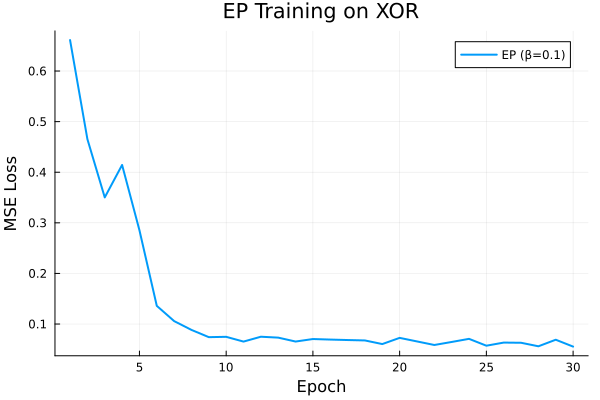

In [14]:
net_train = EPNetwork(2, 32, 1; scale=0.3)
losses = ep_train!(net_train, X_train, y_train;
                   beta=0.1, lr=0.01, epochs=30, T_free=100, T_nudge=50)

plot(losses, xlabel="Epoch", ylabel="MSE Loss",
     title="EP Training on XOR", lw=2, label="EP (β=0.1)",
     legend=:topright)

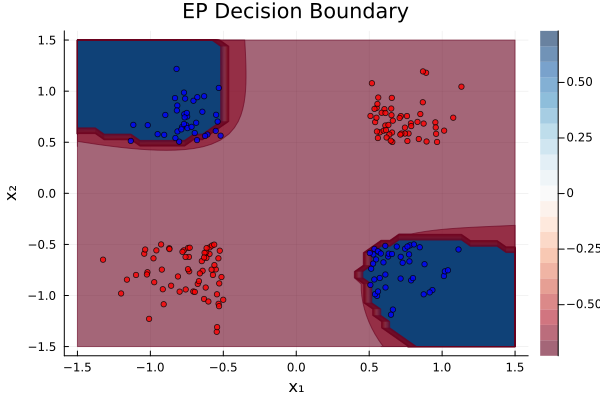

In [15]:
# Visualize decision boundary
function predict_ep(net, x; T=100)
    h = zeros(size(net.W1, 1))
    o = zeros(size(net.W2, 1))
    ep_settle!(net, x, h, o, [0.0], 0.0; T=T)
    return o[1]
end

xx = range(-1.5, 1.5, length=50)
yy = range(-1.5, 1.5, length=50)
Z = [predict_ep(net_train, [xi, yi]) for yi in yy, xi in xx]

contourf(xx, yy, Z, levels=20, color=:RdBu, alpha=0.6,
         title="EP Decision Boundary", xlabel="x₁", ylabel="x₂")
scatter!(X_train[1,:], X_train[2,:],
         color=[(y > 0 ? :blue : :red) for y in y_train],
         markersize=3, legend=false, alpha=0.8)

## 7. Key Takeaways

1. **EP uses a single type of computation** (settling to energy minimum) for both
   inference and gradient computation — no separate backward pass.

2. **The gradient is encoded in the difference** between free and nudged equilibria.
   Each synapse only needs to observe its local pre/post activities in both phases.

3. **Small β gives exact gradients but weak signal.** Large β gives strong signal
   but biased gradients. This is the fundamental dilemma that holomorphic EP resolves.

4. **Symmetric weights** ($W^\top$ in feedback) are required for the energy to be
   well-defined and for the gradient theorem to hold.

Next notebook: **Holomorphic EP** — extending $\beta$ to the complex plane to get
exact gradients at finite nudge amplitude.